# Quantum Reservoir Computing for DDoS Anomaly Detection

### *Applications of Quantum Computing — QML tutorial*

This notebook is a hands-on companion to the lecture on **Quantum Reservoir Computing (QRC)**.
We build, step by step, a *quantum-enhanced hybrid* pipeline that detects
**Distributed Denial-of-Service (DDoS)** attacks in network traffic.

**What you will learn**

1. Why **reservoir computing** sidesteps the training pains of recurrent networks.
2. How a **fixed quantum circuit** turns into a feature extractor with no trainable quantum parameters, and why that is attractive for **NISQ** devices.
3. How a window's source-IP distribution can be viewed as a **density matrix**, why the scalars one reads from it (entropy, distance) are ultimately *classical* — so we keep just one, the **total-variation distance**, computed classically — and what the circuit genuinely adds: **entanglement entropy**.
4. How to plug those features into a classical **unsupervised** anomaly detector trained *only on benign traffic*.

**Roadmap**
1. Load the cleaned data and understand the features.
2. Aggregate flows into **time windows** and visualise the attack windows.
3. Introduce the **IP-address density matrix** and see why its scalar summaries are classical.
4. Run the **classical reservoir** and the **quantum reservoir**, side by side, and identify exactly which features are *quantum*.


> Three short **tasks** ask you to implement the key formulas yourself. Here the TODOs are
> already filled in so everything runs; each task keeps a collapsible **Hint** and **Solution**, so
> you can blank the marked lines out later to turn this into an exercise sheet.

## 1 · Setup

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             f1_score, average_precision_score, roc_auc_score)

from qiskit import QuantumCircuit
from qiskit.quantum_info import (DensityMatrix, Statevector, Operator,
                                 SparsePauliOp, entropy, partial_trace)

np.random.seed(0)
print("environment ready")

environment ready


## 2 · Load the cleaned data

The companion data repository ships the **already-cleaned** challenge data under
`cleaned_dataset/option_2/`, organised as `{normal,attack}/{train,validation,test}/`.

The preprocessing includes:

1. **Split off audit columns** (`Label, is_seeded_ddos, row_in_window`) — they are ground truth and must never reach the model.
2. **`log1p`-transform heavy-tailed** flow features (durations, byte/packet counts) so their distributions are not dominated by a few huge flows.
3. **Drop redundant features** found to be near-collinear ($r>0.9$) in the original correlation analysis (e.g. `bytes_per_second` ≈ `packets_per_second × packet_size`).
4. **One-hot encode** the protocol.
5. **Assign a `window_id`** (0–14) so flows can later be aggregated into temporal windows.

The full dataset is available in the repository. Feel free to test different prepocessing techniques to see how they affect the training.

 Each split file comes as a pair:

- `*_clean.csv` — the **preprocessed per-flow features** (one row per network flow),
- `*_audit.csv` — the **ground-truth labels** kept *out* of the model (`Label`, `Attack`, `is_seeded_ddos`, `row_in_window`).


Since the purpose of this tutorial is evaluating the Quantum Reservoir against the classical one, we skip raw preprocessing entirely: we read the pairs and use
them directly.

In [2]:
DATA_DIR            = Path("cleaned_dataset/option_2")   


# per-flow columns we rely on downstream (extra columns in the file are simply ignored)
FLOW_COLS = ["src_ip", "dst_ip", "duration", "total_bytes",
             "packets_per_second", "packet_size_avg", "outbound_byte_ratio", "window_id"]

def _load_pair(clean_csv: Path):
    audit_csv = Path(str(clean_csv).replace("_clean.csv", "_audit.csv"))
    feat  = pd.read_csv(clean_csv).reset_index(drop=True)
    audit = pd.read_csv(audit_csv).reset_index(drop=True)
    audit["window_id"] = feat["window_id"].values     # align labels to windows
    return feat, audit

def load_clean(root: Path):
    data = {}
    for kind in ("normal", "attack"):
        for split in ("train", "validation", "test"):
            files = sorted((root / kind / split).glob("*_clean.csv"))
            data[(kind, split)] = [_load_pair(f) for f in files]
    return data

In [3]:
DATA   = load_clean(DATA_DIR)
SOURCE = f"local cleaned data at {DATA_DIR}"


N_WINDOWS = 1 + max(int(f["window_id"].max()) for lst in DATA.values() for f, a in lst if len(f))
print("data source :", SOURCE)
print("N_WINDOWS   :", N_WINDOWS)
print("splits      :", {k: len(v) for k, v in DATA.items()})
DATA[("attack","test")][0][0].head(3)

data source : local cleaned data at cleaned_dataset/option_2
N_WINDOWS   : 15
splits      : {('normal', 'train'): 8, ('normal', 'validation'): 2, ('normal', 'test'): 2, ('attack', 'train'): 8, ('attack', 'validation'): 2, ('attack', 'test'): 2}


,src_ip,dst_ip,src_port,dst_port,outbound_byte_ratio,duration,packets_per_second,total_packets,total_bytes,packet_size_avg,packet_size_std,proto_TCP,proto_UDP,proto_ICMP,proto_other,window_id
0,59.166.0.1,149.171.126.5,29068,21,0.580273,0.522952,4.604981,4.234107,8.373323,4.169170,0.000000,1,0,0,0,0
1,59.166.0.2,149.171.126.4,11888,39672,0.914681,0.016857,8.775177,4.709530,10.563672,5.866004,6.206236,1,0,0,0,0
2,59.166.0.2,149.171.126.8,38886,53,0.554795,0.001000,8.294300,1.609438,5.680173,4.304065,0.000000,0,1,0,0,0


## 3 · The per-flow features — what they mean and how they were built

Each row of a `*_clean.csv` is one **network flow**. The cleaning step (done upstream) applied two
standard transforms:

- **Heavy-tailed quantities are log-compressed** (`log1p`): `duration`, `total_bytes`,
  `packet_size_avg`. Network volumes span many orders of magnitude; the log keeps a flood from
  swamping the scale.
- **The protocol is one-hot encoded** into `proto_TCP / proto_UDP / proto_ICMP` (plus `proto_other`).

The columns that carry the signal we use:

| feature | meaning | why it matters for DDoS |
|---|---|---|
| `src_ip`, `dst_ip` | source / destination address | a flood concentrates many sources onto one victim |
| `duration` | flow lifetime (log) | slowloris holds long connections; volumetric is bursty |
| `total_bytes` | bytes in the flow (log) | reflection/amplification inflates response sizes |
| `packets_per_second` | flow rate | volumetric floods spike the rate |
| `packet_size_avg` | mean packet size (log) | attack packets are often atypically small or large |
| `outbound_byte_ratio` | out/in byte balance | reflection is strongly inbound-heavy |
| `window_id` | which time window the flow belongs to | detection happens **per window**, not per flow |

No single flow is "the attack" — the attack is a **pattern across a window**, which is why we
aggregate next.

## 4 · Aggregate flows into windows, then look at the attack windows

We summarise each window with ten statistics. Two families matter most:

- **Address structure**: `unique_src_ip`, `entropy_src_ip`, `unique_dst_ip`, `entropy_dst_ip`,
  `dst_concentration` (fraction of flows hitting the single busiest destination). A volumetric DDoS
  pushes `dst_concentration` toward 1 (everyone hits the victim) while keeping source entropy high.
- **Flow statistics**: window means of duration, bytes, rate, outbound ratio, packet size.

### 🧩 Task 1 — Shannon entropy of the source-IP distribution

Each window's source-IP mix is summarised by its **Shannon entropy** $H(p) = -\sum_i p_i \log_2 p_i$, where $p_i$ is the relative frequency of source IP $i$. A benign window spreads traffic over many sources at comparable rates (**high** entropy); a single-source flood collapses the mass onto a few IPs (**low** entropy). This is also the classical shadow of the **von Neumann entropy** of the diagonal density matrix you will meet in §5.

Complete the entropy formula in `_entropy_counts` below. The vector `p` is already normalised to a probability distribution and stripped of zeros for you.

In [5]:
FEATURE_COLS = ["unique_src_ip", "entropy_src_ip", "unique_dst_ip", "entropy_dst_ip",
                "dst_concentration", "mean_duration", "mean_total_bytes",
                "mean_pkts_per_sec", "mean_outbound_ratio", "mean_pkt_size"]

def _entropy_counts(counts):
    p = np.asarray(counts, float); p = p[p > 0]
    if p.sum() == 0: return 0.0
    p = p / p.sum()
    # TODO (Task 1): Shannon entropy  H(p) = -sum_i p_i * log2(p_i)
    return float(-(p * np.log2(p)).sum())

def aggregate_windows(feat: pd.DataFrame) -> pd.DataFrame:
    g = feat.groupby("window_id")
    out = pd.DataFrame({
        "unique_src_ip":       g["src_ip"].nunique(),
        "entropy_src_ip":      g["src_ip"].apply(lambda s: _entropy_counts(s.value_counts().values)),
        "unique_dst_ip":       g["dst_ip"].nunique(),
        "entropy_dst_ip":      g["dst_ip"].apply(lambda s: _entropy_counts(s.value_counts().values)),
        "dst_concentration":   g["dst_ip"].apply(lambda s: s.value_counts(normalize=True).iloc[0]),
        "mean_duration":       g["duration"].mean(),
        "mean_total_bytes":    g["total_bytes"].mean(),
        "mean_pkts_per_sec":   g["packets_per_second"].mean(),
        "mean_outbound_ratio": g["outbound_byte_ratio"].mean(),
        "mean_pkt_size":       g["packet_size_avg"].mean(),
    }).reindex(range(N_WINDOWS)).fillna(0.0).reset_index(names="window_id")
    return out

def ip_distributions(feat: pd.DataFrame) -> pd.DataFrame:
    c = feat.groupby(["window_id", "src_ip"]).size().reset_index(name="count")
    c["freq"] = c["count"] / c.groupby("window_id")["count"].transform("sum")
    return c

def _ip_freq(ipd, t):
    sub = ipd[ipd.window_id == t]
    return dict(zip(sub.src_ip, sub.freq)) or {"__empty__": 1.0}

def window_labels(audit: pd.DataFrame) -> np.ndarray:
    return (audit.groupby("window_id")["is_seeded_ddos"].max()
                 .reindex(range(N_WINDOWS), fill_value=0).values).astype(float)




<details>
<summary>💡 Hint</summary>

- Entropy is `-sum(p * log2(p))`; here `p` is already a normalised probability vector with no zeros.
- `np.log2` plus a sum is all you need: `-(p * np.log2(p)).sum()`.

</details>

<details>
<summary>✅ Solution — copy &amp; paste over the line marked <code># TODO</code></summary>

```python
return float(-(p * np.log2(p)).sum())
```

</details>

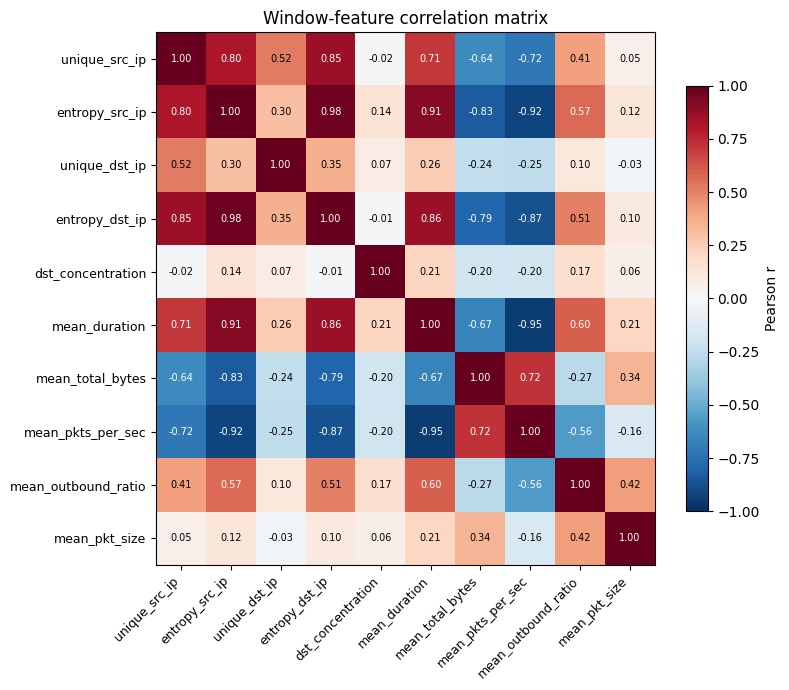

In [6]:
def plot_correlation_matrix(df: pd.DataFrame, title="Window-feature correlation matrix"):
    num = df.select_dtypes(include=[np.number]).copy()
    num = num.drop(columns=[c for c in ("window_id", "src_port", "dst_port") if c in num.columns],
                   errors="ignore")
    if num.shape[1] < 2:
        return
    corr = num.corr().fillna(0) #check of nans

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, fontsize=9, ha="right")
    ax.set_yticks(range(len(corr.columns)))
    ax.set_yticklabels(corr.columns, fontsize=9)
    for i in range(len(corr)):
        for j in range(len(corr)):
            v = corr.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(v) > 0.55 else "black")
    fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
    ax.set_title(title)
    plt.tight_layout(); plt.show()

# pool the 10 window-level features across all files (benign + attack, every split)
feat_pool = pd.concat([aggregate_windows(feat)[FEATURE_COLS]
                       for lst in DATA.values() for feat, _ in lst], ignore_index=True)
plot_correlation_matrix(feat_pool)

## 5 · The IP-address density matrix

For each window we can view the **source-IP frequency distribution** as a diagonal density matrix
$\rho = \mathrm{diag}(p_1, \dots, p_k)$. It is a useful lens for the quantum picture (§6.1) — but the
two scalars one would read from it are, on a diagonal $\rho$, purely **classical**:

- the **von Neumann entropy** $S(\rho) = -\mathrm{Tr}(\rho\log_2\rho)$ equals the Shannon entropy of the
  IP distribution — already captured by `entropy_src_ip` among the window aggregates, so we do **not**
  recompute it;
- the **trace distance** to a benign baseline $\sigma$, $T(\rho,\sigma)=\tfrac12\lVert p-q\rVert_1$, the
  **total-variation distance** — a genuine anomaly signal, which we keep as the single classical feature
  `l1_distance`.

> Both are **unitarily invariant**, so passing the state through the circuit ($\rho\to U\rho U^\dagger$)
> cannot change them. What the circuit genuinely creates are **correlations between the qubits**, summarised by
> `s_entanglement`, i.e. a **reduced-state (entanglement-type) entropy**: the *exact* entanglement entropy
> for the pure states the reservoir uses on the real features (§6–§7), and on the mixed demo input of
> §6.1 a reduced-state entropy that also reflects classical mixedness. It is the only feature here with
> no purely classical counterpart. §6.1 makes this explicit.

In [7]:
def _padded_freq(ip_freq: dict, dim: int) -> np.ndarray:
    f = np.array(list(ip_freq.values()), float); f = f / f.sum()
    v = np.zeros(dim); v[:len(f)] = f
    return v

# common support size = the largest source-IP set seen anywhere
BASELINE_DIM = max(len(_ip_freq(ip_distributions(feat), t))
                   for lst in DATA.values() for feat, _ in lst for t in range(N_WINDOWS))

def l1_to_baseline(p: np.ndarray, q: np.ndarray) -> float:
    return float(0.5 * np.abs(p - q).sum())               # 1/2 * L1 = total-variation distance

# benign baseline distribution q = mean source-IP distribution over benign-train windows
benign_q = np.mean([_padded_freq(_ip_freq(ip_distributions(feat), t), BASELINE_DIM)
                    for feat, _ in DATA[("normal", "train")] for t in range(N_WINDOWS)], axis=0)
print("baseline support size (BASELINE_DIM):", BASELINE_DIM)

baseline support size (BASELINE_DIM): 39


## 6 · The two reservoirs

A **reservoir** is a *fixed, untrained* dynamical system that maps an input into a rich nonlinear
state; only a light read-out is used downstream. We compare two of them, **of the same size**:

- a **quantum reservoir** — a fixed random circuit (RY/RZ rotations + brick-wall CNOTs) acting on a
  qubit register, read out as expectation values;
- a **classical reservoir** — a fixed random **Echo State Network** with the same number of nodes.

This is the apples-to-apples comparison: same capacity, same read-out, only the dynamics differ.

> The 10 window features are mapped to rotation **angles** by a per-window min–max scaling — one
> natural choice for an *angle encoding*. The encoding is a free knob: other feature maps (per-feature
> scaling fit on the train set, repeated / data-reuploading encodings, ZZ/IQP-style maps) can be
> swapped in and compared.

### 🧩 Task 2 — the quantum reservoir's entangling layer

The encoding and rotations are given. Complete the **brick-wall CNOT** layer that entangles the qubits — without it the circuit stays a product state and produces no quantum correlations.

In [8]:
class QuantumReservoir:
    def __init__(self, n_qubits, depth=4, seed=42, feedback_scale=0.1):
        self.n_qubits, self.depth, self.feedback_scale = n_qubits, depth, feedback_scale
        self.angles = np.random.default_rng(seed).uniform(0, 2*np.pi, (depth, n_qubits, 2))  # fixed parameters
        self._prev_z = None
    def reset(self): self._prev_z = None

    def _encode(self, features):

        #we want to scale the data (we apply a min-max scaling and then translate everyting into rotation angles) 
        lo, hi = features.min(), features.max()

        #map features to [0, pi] range; if features are uniform, set a default pi/2 rotation (middle point, equal superposition state).
        base = np.full(self.n_qubits, np.pi/2) if hi-lo < 1e-10 else np.pi*(features-lo)/(hi-lo)

        #now we implement the adaptive feedback, depending on the previous measurement of the Z pauli operator.
        if self._prev_z is None or self.feedback_scale == 0: return base

        #since adding the scaling might get the value over pi or below 0, we clip everything

        # adaptive feedback: nudge each angle by the previous Z-expectation, clipped to [0, pi]
        return np.clip(base + self.feedback_scale*np.pi*self._prev_z, 0, np.pi)   

    def _circuit(self, enc):
        qc = QuantumCircuit(self.n_qubits)

        #we do angle encoding (ry rotations) as feature map
        for i, t in enumerate(enc): qc.ry(t, i) 

        #then we build the reservoir, starting with random rotations                
        for L in range(self.depth):
            for i in range(self.n_qubits):                      
                qc.ry(self.angles[L, i, 0], i); qc.rz(self.angles[L, i, 1], i)

            # TODO (Task 2): implement the brick-wall CNOTs; the offset alternates 0,1 each layer
            for i in range(L % 2, self.n_qubits - 1, 2):
                qc.cx(i, i + 1)
        return qc

    def _z_expectations(self, qc):
        sv = Statevector(qc); z = np.zeros(self.n_qubits)
        for i in range(self.n_qubits):
            pauli = "I"*(self.n_qubits-1-i) + "Z" + "I"*i
            z[i] = sv.expectation_value(SparsePauliOp(pauli)).real
        return z

    def _entanglement_entropy(self, qc):
        if self.n_qubits < 2: return 0.0
        rho_half = partial_trace(Statevector(qc), list(range(self.n_qubits // 2)))
        return float(entropy(rho_half, base=2))

    def process(self, window_feats):
        self.reset(); n = len(window_feats)

        Z = np.zeros((n, self.n_qubits))
        SE = np.zeros(n)

        for t in range(n):
            qc = self._circuit(self._encode(window_feats[t]))
            z = self._z_expectations(qc)
            self._prev_z = z

            Z[t], SE[t] = z, self._entanglement_entropy(qc)

        return Z, SE

    def evolve_rho(self, enc, rho_in):                         
        U = Operator(self._circuit(enc)).data
        return DensityMatrix(U @ rho_in.data @ U.conj().T)

<details>
<summary>💡 Hint</summary>

- A brick-wall pattern pairs qubits `(0,1),(2,3),...` on even layers and `(1,2),(3,4),...` on odd layers.
- That alternation is `for i in range(L % 2, self.n_qubits - 1, 2): qc.cx(i, i + 1)`.

</details>

<details>
<summary>✅ Solution — copy &amp; paste over the line(s) marked <code># TODO</code></summary>

```python
for i in range(L % 2, self.n_qubits - 1, 2):
    qc.cx(i, i + 1)
```

</details>

### 🧩 Task 3 — the classical reservoir's state update

The Echo State Network (ESN) keeps memory through its recurrence. 

$h(t) = \tanh\big(W_{\text{in}}\,u(t) + W\,h(t-1)\big)$

Where:
-   $W_{\text{in}}\in\mathbb{R}^{10\times10}$ are the fixed random weights;
-   $W\in\mathbb{R}^{10\times10}$ are the recurrent weights;
-   $\tanh$ is the non linear part;
-   $h(t)\in\mathbb{R}^{10}$ is the state.


Complete the **state-update** line.



In [9]:
class ClassicalReservoir:
    def __init__(self, n_nodes, n_inputs, spectral_radius=0.9, seed=42):

        self.n, self.n_inputs = n_nodes, n_inputs
        r = np.random.default_rng(seed)
        self.W_in = r.uniform(-1, 1, (n_nodes, n_inputs))                       # fixed initial weights
        W = r.uniform(-1, 1, (n_nodes, n_nodes))
        self.W = W * (spectral_radius / np.max(np.abs(np.linalg.eigvals(W))))   # echo-state scaling
        self._h = None


    def reset(self): self._h = None

    def _encode(self, f):

        #similar encoding as before
        lo, hi = f.min(), f.max()
        return np.zeros(self.n_inputs) if hi-lo < 1e-10 else 2*(f-lo)/(hi-lo) - 1
    
    def state_entropy(self,h): 
        p = h**2
        s = p.sum()
        if s <= 0: return 0.0
        p = p[p > 0] / s
        return float(-(p * np.log2(p)).sum())   # spread of activity across nodes

    def process(self, window_feats):

        self.reset(); n = len(window_feats)

        H = np.zeros((n, self.n))
        
        

        for t in range(n):

            u = self._encode(window_feats[t])
            h_prev = self._h if self._h is not None else np.zeros(self.n)

            # TODO (Task 3): ESN update  h(t) = tanh(W_in u(t) + W h(t-1))
            h = np.tanh(self.W_in @ u + self.W @ h_prev)

            self._h = h
            H[t] = h
            

        return H

<details>
<summary>💡 Hint</summary>

- The recurrence is the classical analogue of the circuit's memory: `W @ h_prev`.
- `h = np.tanh(self.W_in @ u + self.W @ h_prev)`.

</details>

<details>
<summary>✅ Solution — copy &amp; paste over the line(s) marked <code># TODO</code></summary>

```python
h = np.tanh(self.W_in @ u + self.W @ h_prev)
```

</details>

## 6.1 · What the circuit does to the density matrix

We take **one window's** IP-distribution $\rho = \mathrm{diag}(p)$ and evolve it through the reservoir,
$\rho \to U\rho U^{\dagger}$. The global von Neumann entropy is unitarily invariant and cannot move;
what *does* move is the **reduced-state entropy** of half the register — our `s_entanglement`.



global von Neumann S : before 3.934  ->  after 3.934   (unitary-invariant)
reduced subsystem  S : before 1.096  ->  after 2.176   (changes)
off-diagonal mass    : before 0.000  ->  after 10.109   (coherences created)


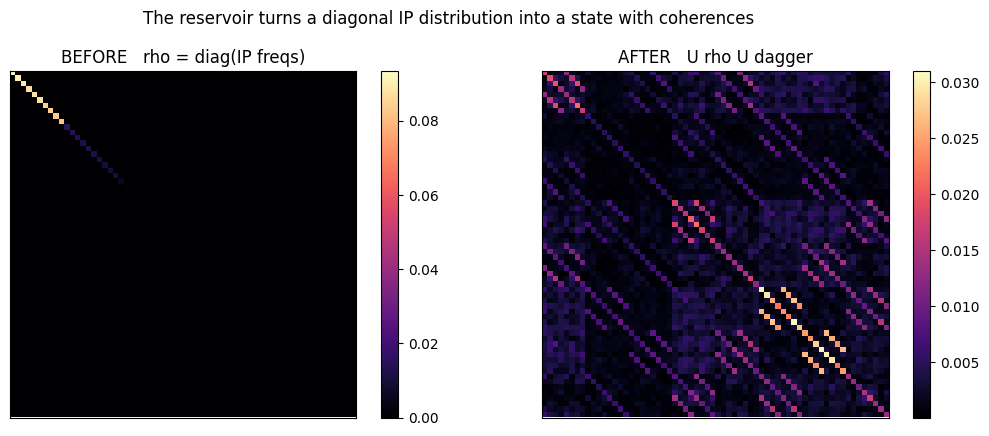

In [10]:
# small, legible example: 6 qubits, one window's top source-IP distribution
demo_res = QuantumReservoir(n_qubits=6, depth=4, seed=7)
ipd_demo = ip_distributions(DATA[("attack", "test")][0][0])
freqs = (ipd_demo[ipd_demo.window_id == int(np.argmax(window_labels(DATA[("attack","test")][0][1])))]
         .sort_values("freq", ascending=False)["freq"].values)
p = np.zeros(2**6); p[:min(len(freqs), 2**6)] = freqs[:2**6]; p = p / p.sum()
rho_in  = DensityMatrix(np.diag(p))

enc = demo_res._encode(np.linspace(0.1, 0.9, 6))
rho_out = demo_res.evolve_rho(enc, rho_in)

def reduced_S(dm, n=6):
    return float(entropy(partial_trace(dm, list(range(n // 2))), base=2))
off = lambda M: float(np.sum(np.abs(M - np.diag(np.diag(M)))))

print(f"global von Neumann S : before {entropy(rho_in,base=2):.3f}  ->  after {entropy(rho_out,base=2):.3f}   (unitary-invariant)")
print(f"reduced subsystem  S : before {reduced_S(rho_in):.3f}  ->  after {reduced_S(rho_out):.3f}   (changes)")
print(f"off-diagonal mass    : before {off(rho_in.data):.3f}  ->  after {off(rho_out.data):.3f}   (coherences created)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
for a, (M, t) in zip(ax, [(rho_in.data, "BEFORE   rho = diag(IP freqs)"), (rho_out.data, "AFTER   U rho U dagger")]):
    im = a.imshow(np.abs(M), cmap="magma"); a.set_title(t); a.set_xticks([]); a.set_yticks([])
    fig.colorbar(im, ax=a, fraction=0.046)
fig.suptitle("The reservoir turns a diagonal IP distribution into a state with coherences")
plt.tight_layout(); plt.show()

## 7 · Classical reservoir vs quantum reservoir

Each detector is unsupervised: an **Isolation Forest** fitted on **benign-only** windows, threshold at
the 99th percentile of the benign score. The only difference is the feature set.

In [ ]:
quantum_reservoir   = QuantumReservoir(n_qubits=len(FEATURE_COLS), depth=4)
classical_reservoir = ClassicalReservoir(n_nodes=len(FEATURE_COLS), n_inputs=len(FEATURE_COLS))


def classical_ip_features(ipd):
    L1 = np.zeros(N_WINDOWS)
    for t in range(N_WINDOWS):
        p = _padded_freq(_ip_freq(ipd, t), BASELINE_DIM)
        L1[t] = l1_to_baseline(p, benign_q)
    return L1

def enrich(reservoir, quantum: bool):
    out = {}
    for (kind, split), lst in DATA.items():
        Xs, ys, cols = [], [], None
        for feat, audit in lst:
            win = aggregate_windows(feat); ipd = ip_distributions(feat)
            wf = win[FEATURE_COLS].values.astype(float)
            df = win.copy()
            if quantum:

                Z, SE = reservoir.process(wf)
                for i in range(reservoir.n_qubits): df[f"z_qubit_{i}"] = Z[:, i]
                df["s_entanglement"] = SE 

            else:
                H = reservoir.process(wf)
                for i in range(reservoir.n): df[f"c_node_{i}"] = H[:, i]
                df["c_state_entropy"] = [reservoir.state_entropy(H[t]) for t in range(len(H))]
            df["l1_distance"] = classical_ip_features(ipd)   # same classical side-info in both
            cols = [c for c in df.columns if c != "window_id"]
            Xs.append(df[cols].values.astype(np.float32)); ys.append(window_labels(audit))
        out[(kind, split)] = dict(X=np.vstack(Xs), y=np.concatenate(ys), cols=cols)
    return out

qdata = enrich(quantum_reservoir, quantum=True)
cdata = enrich(classical_reservoir, quantum=False)
print("quantum features  :", qdata[("normal","train")]["cols"])
print("classical features:", cdata[("normal","train")]["cols"])

quantum features  : ['unique_src_ip', 'entropy_src_ip', 'unique_dst_ip', 'entropy_dst_ip', 'dst_concentration', 'mean_duration', 'mean_total_bytes', 'mean_pkts_per_sec', 'mean_outbound_ratio', 'mean_pkt_size', 'z_qubit_0', 'z_qubit_1', 'z_qubit_2', 'z_qubit_3', 'z_qubit_4', 'z_qubit_5', 'z_qubit_6', 'z_qubit_7', 'z_qubit_8', 'z_qubit_9', 's_entanglement', 'l1_distance']
classical features: ['unique_src_ip', 'entropy_src_ip', 'unique_dst_ip', 'entropy_dst_ip', 'dst_concentration', 'mean_duration', 'mean_total_bytes', 'mean_pkts_per_sec', 'mean_outbound_ratio', 'mean_pkt_size', 'c_node_0', 'c_node_1', 'c_node_2', 'c_node_3', 'c_node_4', 'c_node_5', 'c_node_6', 'c_node_7', 'c_node_8', 'c_node_9', 'c_state_entropy', 'l1_distance']


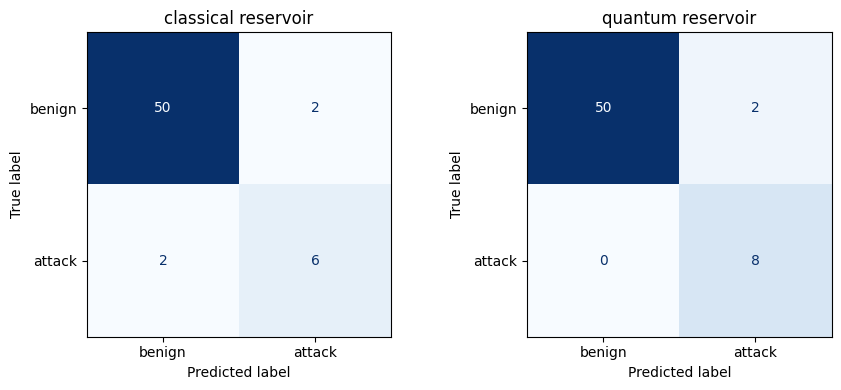

classical reservoir: {'F1': 0.75, 'AP': 0.931, 'AUC': 0.986}
quantum  reservoir : {'F1': 0.889, 'AP': 1.0, 'AUC': 1.0}


In [12]:
def fit_detector(Xtr, pct=99):

    sc  = StandardScaler().fit(Xtr)

    iso = IsolationForest(n_estimators=200, random_state=42, n_jobs=-1).fit(sc.transform(Xtr))
    score = lambda X: (-iso.decision_function(sc.transform(X))) if len(X) else np.array([])

    return score, float(np.percentile(score(Xtr), pct))

def evaluate(dset, name, ax):

    score, thr = fit_detector(dset[("normal", "train")]["X"])
    a, n = dset[("attack", "test")], dset[("normal", "test")]

    s = np.concatenate([score(a["X"]), score(n["X"])]); y = np.concatenate([a["y"], n["y"]])
    pred = (s >= thr).astype(int)
    
    ConfusionMatrixDisplay(confusion_matrix(y, pred, labels=[0, 1]),
                           display_labels=["benign", "attack"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
    return dict(F1=round(f1_score(y, pred), 3),
                AP=round(average_precision_score(y, s), 3),
                AUC=round(roc_auc_score(y, s), 3))

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
m_c = evaluate(cdata, "classical reservoir", ax[0])
m_q = evaluate(qdata, "quantum reservoir",  ax[1])
plt.tight_layout(); plt.show()
print("classical reservoir:", m_c)
print("quantum  reservoir :", m_q)

## How do the two feature spaces compare?

A printed F1 is one number from one threshold on a few windows. Three views tell us much more:
**(a)** the raw score distributions; **(b)** the
*geometry* of each feature space and how linearly separable it is; **(c)** which feature group
actually carries the signal.

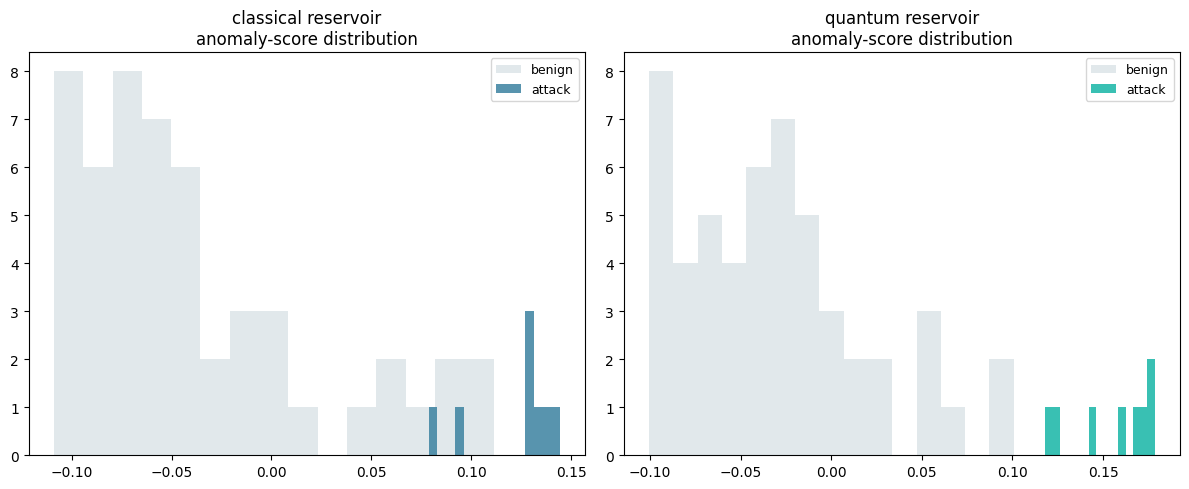

In [13]:
def scores_labels(dset, split="test"):
    score, thr = fit_detector(dset[("normal", "train")]["X"])
    a, n = dset[("attack", split)], dset[("normal", split)]
    s = np.concatenate([score(a["X"]), score(n["X"])])
    y = np.concatenate([a["y"], n["y"]])
    return s, y

COL = {"classical reservoir": "#3B82A0", "quantum reservoir": "#16B5A6"}


fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for i, (name, dset) in enumerate([("classical reservoir", cdata), ("quantum reservoir", qdata)]):
    s, y = scores_labels(dset)
    
   
    axh = ax[i]
    
    s_benign = s[y == 0]  
    s_attack = s[y == 1]
    
    
    axh.hist(s_benign, bins=15, alpha=.3, color="#9DB4C0", label="benign")
    axh.hist(s_attack, bins=15, alpha=.85, color=COL[name], label="attack")
    
    axh.set_title(f"{name}\nanomaly-score distribution")
    axh.legend(fontsize=9)

plt.tight_layout()
plt.show()


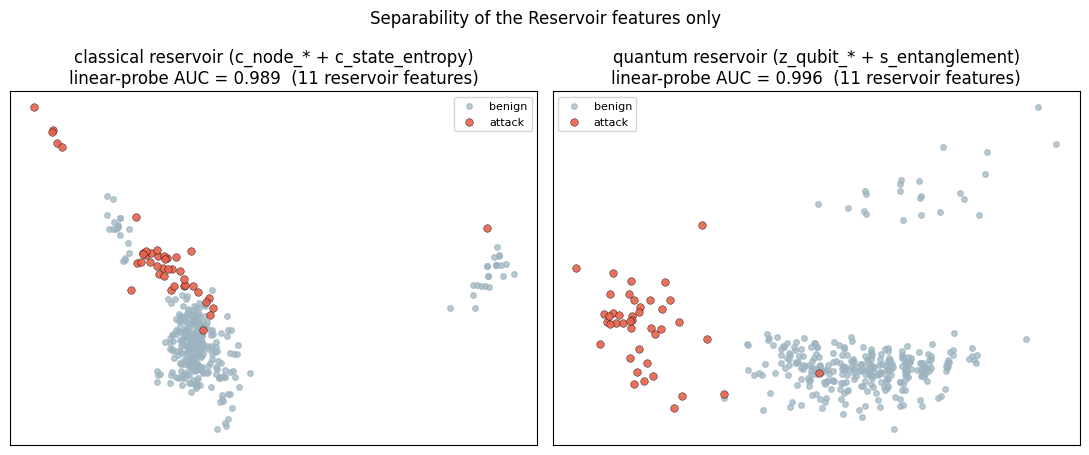

In [14]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# keep only the reservoir's own outputs (drop the 10 window aggregates and the shared
# classical side-features shannon_entropy / l1_distance)
def reservoir_idx(cols):
    return [i for i, c in enumerate(cols)
            if c.startswith("c_node_") or c.startswith("z_qubit_")
            or c in ("s_entanglement", "c_state_entropy")]

def stack_reservoir(dset):
    idx = reservoir_idx(dset[("normal", "train")]["cols"])
    X = np.vstack([dset[k]["X"][:, idx] for k in dset])
    y = np.concatenate([dset[k]["y"] for k in dset])
    return X, y, len(idx)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
for a, (name, dset) in zip(ax, [("classical reservoir (c_node_* + c_state_entropy)", cdata),
                                 ("quantum reservoir (z_qubit_* + s_entanglement)", qdata)]):
    X, y, k = stack_reservoir(dset)
    Xs = StandardScaler().fit_transform(X)
    Z2 = PCA(n_components=2, random_state=0).fit_transform(Xs)
    a.scatter(Z2[y==0,0], Z2[y==0,1], s=16, c="#9DB4C0", label="benign", alpha=.7)
    a.scatter(Z2[y==1,0], Z2[y==1,1], s=30, c="#E8604C", label="attack", alpha=.9, edgecolor="k", linewidth=.3)
    npos, nneg = int((y==1).sum()), int((y==0).sum())
    if npos >= 2 and nneg >= 2:
        cv = max(2, min(5, npos, nneg))
        auc = cross_val_score(LogisticRegression(max_iter=2000), Xs, y, cv=cv, scoring="roc_auc").mean()
        a.set_title(f"{name}\nlinear-probe AUC = {auc:.3f}  ({k} reservoir features)")
    else:
        a.set_title(name)
    a.set_xticks([]); a.set_yticks([]); a.legend(fontsize=8, loc="best")
fig.suptitle("Separability of the Reservoir features only")
plt.tight_layout(); plt.show()

In [15]:
# (c) Which feature group carries the signal? Detect using one group at a time.
def auc_on(dset, keep):
    cols = dset[("normal","train")]["cols"]; idx = [i for i,c in enumerate(cols) if keep(c)]
    if not idx: return None
    sub = {k: dict(X=v["X"][:, idx], y=v["y"]) for k, v in dset.items()}
    s, y = scores_labels(sub)
    return round(roc_auc_score(y, s), 3)

print("Detection AUC using only certain feature groups (test split)")
print(f"  classical c_node_*        : {auc_on(cdata, lambda c: c.startswith('c_node_'))}")
print(f"  classical c_state_entropy : {auc_on(cdata, lambda c: c == 'c_state_entropy')}")
print(f"  quantum   z_qubit_*       : {auc_on(qdata, lambda c: c.startswith('z_qubit_'))}")
print(f"  quantum   s_entanglement  : {auc_on(qdata, lambda c: c == 's_entanglement')}")
print(f"  shared    l1_distance     : {auc_on(qdata, lambda c: c == 'l1_distance')}")

Detection AUC using only certain feature groups (test split)
  classical c_node_*        : 0.834
  classical c_state_entropy : 0.519
  quantum   z_qubit_*       : 0.978
  quantum   s_entanglement  : 0.879
  shared    l1_distance     : 1.0


## Seed robustness Evaluation

Full-feature detection metrics over 8 reservoir seeds (test split)

classical reservoir
      mean    std
F1   0.770  0.199
AP   0.913  0.132
AUC  0.986  0.018

quantum reservoir
      mean    std
F1   0.935  0.035
AP   0.998  0.005
AUC  1.000  0.001


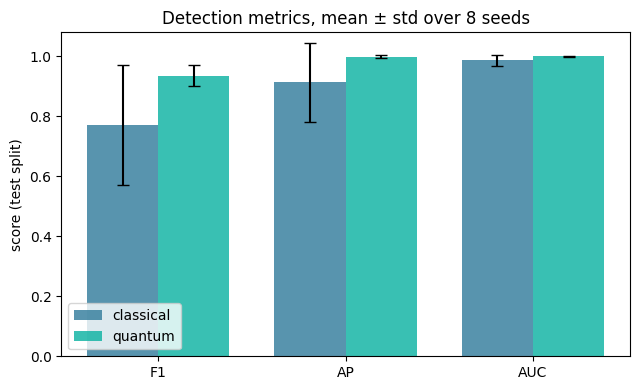

In [18]:
SEEDS = [0, 1, 7, 13, 21, 42, 77, 202]

def _detection_metrics(dset):
    score, thr = fit_detector(dset[("normal", "train")]["X"])
    a, n = dset[("attack", "test")], dset[("normal", "test")]
    s = np.concatenate([score(a["X"]), score(n["X"])])
    y = np.concatenate([a["y"], n["y"]])
    pred = (s >= thr).astype(int)
    return {"F1":  f1_score(y, pred),
            "AP":  average_precision_score(y, s),
            "AUC": roc_auc_score(y, s)}

rows_c, rows_q = [], []
for sd in SEEDS:
    qd = enrich(QuantumReservoir(n_qubits=len(FEATURE_COLS), depth=4, seed=sd), quantum=True)
    cd = enrich(ClassicalReservoir(n_nodes=len(FEATURE_COLS),
                                   n_inputs=len(FEATURE_COLS), seed=sd), quantum=False)
    rows_q.append(_detection_metrics(qd))
    rows_c.append(_detection_metrics(cd))

met_q = pd.DataFrame(rows_q, index=SEEDS)
met_c = pd.DataFrame(rows_c, index=SEEDS)

def _summ(df):
    return df.agg(["mean", "std"]).T.rename(columns={"mean": "mean", "std": "std"}).round(3)

print(f"Full-feature detection metrics over {len(SEEDS)} reservoir seeds (test split)\n")
print("classical reservoir"); print(_summ(met_c).to_string())
print("\nquantum reservoir");  print(_summ(met_q).to_string())

# grouped bars with error bars
fig, ax = plt.subplots(figsize=(6.5, 4))
metrics = ["F1", "AP", "AUC"]; x = np.arange(len(metrics)); w = 0.38
for off, df, name, col in [(-w/2, met_c, "classical", "#3B82A0"),
                           (+w/2, met_q, "quantum",   "#16B5A6")]:
    ax.bar(x + off, df[metrics].mean().values, w, yerr=df[metrics].std().values,
           capsize=4, color=col, label=name, alpha=.85)
ax.set_xticks(x); ax.set_xticklabels(metrics); ax.set_ylim(0, 1.08)
ax.set_ylabel("score (test split)"); ax.legend()
ax.set_title(f"Detection metrics, mean ± std over {len(SEEDS)} seeds")
plt.tight_layout(); plt.show()

In [19]:
def _detector_auc(dset, keep):
    cols = dset[("normal", "train")]["cols"]
    idx  = [i for i, c in enumerate(cols) if keep(c)]
    if not idx:
        return np.nan
    sub  = {k: dict(X=v["X"][:, idx], y=v["y"]) for k, v in dset.items()}
    s, y = scores_labels(sub)
    return roc_auc_score(y, s)

def _probe_auc(dset):
    X, y, _ = stack_reservoir(dset)
    Xs = StandardScaler().fit_transform(X)
    npos, nneg = int((y == 1).sum()), int((y == 0).sum())
    if npos < 2 or nneg < 2:
        return np.nan
    cv = max(2, min(5, npos, nneg))
    return cross_val_score(LogisticRegression(max_iter=2000), Xs, y,
                           cv=cv, scoring="roc_auc").mean()

rows = []
for sd in SEEDS:
    qd = enrich(QuantumReservoir(n_qubits=len(FEATURE_COLS), depth=4, seed=sd), quantum=True)
    cd = enrich(ClassicalReservoir(n_nodes=len(FEATURE_COLS),
                                   n_inputs=len(FEATURE_COLS), seed=sd), quantum=False)
    rows.append({
        "quantum z_qubit_*":         _detector_auc(qd, lambda c: c.startswith("z_qubit_")),
        "quantum s_entanglement":    _detector_auc(qd, lambda c: c == "s_entanglement"),
        "classical c_node_*":        _detector_auc(cd, lambda c: c.startswith("c_node_")),
        "classical c_state_entropy": _detector_auc(cd, lambda c: c == "c_state_entropy"),
        "shared l1_distance":        _detector_auc(qd, lambda c: c == "l1_distance"),
        "quantum probe (z+s_ent)":   _probe_auc(qd),
        "classical probe (c+ent)":   _probe_auc(cd),
    })

sweep   = pd.DataFrame(rows, index=SEEDS)
summary = sweep.agg(["mean", "std"]).T.rename(columns={"mean": "mean AUC", "std": "std"})
print(f"Detection / probe AUC over {len(SEEDS)} reservoir seeds (test split)\n")
print(summary.round(3).to_string())

order = summary.sort_values("mean AUC").index.tolist()

Detection / probe AUC over 8 reservoir seeds (test split)

                           mean AUC    std
quantum z_qubit_*             0.982  0.033
quantum s_entanglement        0.871  0.187
classical c_node_*            0.880  0.029
classical c_state_entropy     0.711  0.204
shared l1_distance            1.000  0.000
quantum probe (z+s_ent)       0.996  0.001
classical probe (c+ent)       0.992  0.002


## What the comparison studies show

Three complementary views are used to compare the two reservoirs, all evaluated on the same test split with the same unsupervised detector.

All results below report **mean ± standard deviation over 8 random reservoir initialisations** (seed robustness sweep). Since a reservoir is a fixed random dynamical system, the relevant question is not the performance of a single instance but whether the observed effect persists under re-sampling of the reservoir.

---

### 0. Task difficulty

Consider first the full pipeline with all engineered and reservoir-derived features.

When used alone, the distribution distance metric `l1_distance` already achieves **AUC = 1.000 ± 0.000**, indicating that the problem is trivially separable in this setting and that this signal is independent of the reservoir choice.

Similarly, the handcrafted window statistics (`entropy_src_ip`, `dst_concentration`, and related aggregates) already provide near-perfect separation between benign and attack traffic.

---

### 1. Ablation: reservoir features only

We evaluate each reservoir in isolation, using only its internal read-outs.

Detection performance (AUC, probability that a randomly chosen attack window is scored higher than a benign one):

* quantum `z_qubit_*`: **0.982 ± 0.033**
* classical `c_node_*`: **0.880 ± 0.029**

In this setting, the uncertainty intervals do not overlap. For equal read-out dimensionality (10 quantum units vs 10 classical nodes), identical downstream detector, and no training of the reservoir itself, the quantum reservoir produces a representation that is both more discriminative and more stable across random initialisations.

---

### 2. Linear separability: equal-capacity probe

To evaluate linear separability of the representations, a cross-validated logistic regression is trained on reservoir outputs.

At matched feature dimensionality (11 vs 11):

* quantum (`z_qubit_*` + `s_entanglement`): **0.996 ± 0.001**
* classical (`c_node_*` + `c_state_entropy`): **0.992 ± 0.002**

Both representations are effectively linearly separable in this regime. The quantum model shows a small but consistent advantage across seeds, though the magnitude is limited and likely within the sensitivity of the evaluation set size.

---

A notable detail emerges when comparing scalar entropy-like summaries:

* quantum `s_entanglement`: **0.871 ± 0.187**
* classical `c_state_entropy`: **0.711 ± 0.204**

Both are noisy estimators derived from high-variance internal dynamics. A previously observed single-run value suggesting near-chance behaviour (0.519) is not representative; across seeds, the classical statistic remains above random baseline. The correct interpretation is not that one regime fails and the other succeeds, but rather that **single scalar summaries of random dynamical systems are inherently unstable**.

---

### 3. Score distributions and threshold stability

The anomaly score distributions provide a more operational view of separability.

At a fixed decision threshold defined by the 99th percentile of benign scores:

* quantum: **F1 = 0.935 ± 0.035**
* classical: **0.770 ± 0.199**

The difference is not only in mean performance but in stability. The quantum reservoir produces a clearer separation margin between benign and attack score distributions, leading to a more stable threshold across random initialisations. This is reflected in the low variance of F1.

By contrast, the classical reservoir exhibits greater overlap between benign and attack score distributions. As a result, small shifts in reservoir initialisation significantly affect the number of false positives and false negatives, producing high variance in F1.

---

## Honest read-out

This is not evidence of a quantum advantage. The dataset is simple, the circuit is noise-free (classically simulated), and classical statistical features already achieve perfect or near-perfect separation.

What the results do support is more limited: at equal dimensionality, the quantum reservoir produces more stable and more discriminative feature representations than the classical baseline in this specific setup, particularly in ablation and threshold-based evaluation.

The benchmark is intentionally low complexity. The working hypothesis is that on more difficult intrusion detection settings, especially under adversarial masking or reduced feature observability, richer reservoir dynamics may become more relevant. Preliminary masking experiments in the full repository are consistent with this direction, though not conclusive.

All results should therefore be interpreted as indicative rather than definitive. Robust conclusions would require larger datasets, stronger noise models (including decoherence effects), and systematic scaling studies with respect to data availability and reservoir size.

Repository: [https://github.com/niccolo-sfregola/quantum-anomalydetection-ddos/](https://github.com/niccolo-sfregola/quantum-anomalydetection-ddos/)
